# Divergences Between Gaussians: Closed-Form Expressions

Many statistical and geometric distances between probability distributions admit **closed-form expressions** when both distributions are Gaussian. For univariate Gaussians $p_1 = \mathcal{N}(m_1, \sigma_1^2)$ and $p_2 = \mathcal{N}(m_2, \sigma_2^2)$, the four most important divergences are:

## Kullback–Leibler divergence
$$
\mathrm{KL}(p_1 \| p_2) = \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (m_1-m_2)^2}{2\sigma_2^2} - \frac{1}{2}.
$$
Note: $\mathrm{KL}(p_1 \| p_2) \neq \mathrm{KL}(p_2 \| p_1)$ — the KL divergence is **asymmetric**.

## Hellinger distance
$$
H^2(p_1, p_2) = 2 - 2\sqrt{\frac{2\sigma_1 \sigma_2}{\sigma_1^2 + \sigma_2^2}} \exp\!\left(-\frac{(m_1-m_2)^2}{4(\sigma_1^2+\sigma_2^2)}\right).
$$
The Hellinger distance is symmetric and bounded: $H \in [0, \sqrt{2}]$.

## Wasserstein-2 distance
The quadratic Wasserstein (optimal transport) distance between Gaussians is:
$$
W_2(p_1, p_2) = \sqrt{(m_1-m_2)^2 + (\sigma_1 - \sigma_2)^2}.
$$
Remarkably, this is the **Euclidean distance** in the $(m, \sigma)$ parameter space.

## Fisher–Rao geodesic distance
The Fisher information metric on the Gaussian manifold gives a Riemannian metric. The geodesic distance is:
$$
d_{\text{Fisher}}(p_1, p_2) = \sqrt{2}\,\log\!\left(\frac{F(m_1,\sigma_1,m_2,\sigma_2) + (m_1-m_2)^2 + 2(\sigma_1^2+\sigma_2^2)}{4\sigma_1\sigma_2}\right),
$$
where $F = \sqrt{((m_1-m_2)^2 + 2(\sigma_1-\sigma_2)^2)((m_1-m_2)^2 + 2(\sigma_1+\sigma_2)^2)}$.

## Geometry of the Gaussian family

Each divergence defines a different **geometry on the upper half-plane** $\mathcal{H} = \{(m, \sigma) : \sigma > 0\}$. The Fisher–Rao metric makes $\mathcal{H}$ isometric to the **Poincaré half-plane** (constant negative curvature $-\frac{1}{2}$), while the Wasserstein-2 distance gives the Euclidean metric on $\mathcal{H}$.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

plt.rcParams['figure.dpi'] = 120

## Closed-form divergence functions

We implement the four divergences as vectorized functions accepting arrays of $(m, \sigma)$ values.

In [2]:
def kl(m1, s1, m2, s2):
    """KL(N(m1,s1^2) || N(m2,s2^2))"""
    return np.log(s2/s1) + (s1**2 + (m1-m2)**2) / (2*s2**2) - 0.5

def kl_sym(m1, s1, m2, s2):
    """Symmetric KL = KL(p1||p2) + KL(p2||p1)"""
    return kl(m1, s1, m2, s2) + kl(m2, s2, m1, s1)

def hellinger(m1, s1, m2, s2):
    """Hellinger distance H(p1, p2)"""
    A = np.sqrt(2*s1*s2 / (s1**2 + s2**2)) * np.exp(-(m1-m2)**2 / (4*(s1**2+s2**2)))
    return np.sqrt(np.maximum(2 - 2*A, 0))

def wasserstein2(m1, s1, m2, s2):
    """Wasserstein-2 distance (Gaussian case)"""
    return np.sqrt((m1-m2)**2 + (s1-s2)**2)

def fisher_rao(m1, s1, m2, s2):
    """Fisher-Rao geodesic distance on the Gaussian manifold."""
    dm2 = (m1-m2)**2
    F = np.sqrt((dm2 + 2*(s1-s2)**2) * (dm2 + 2*(s1+s2)**2))
    arg = (F + dm2 + 2*(s1**2 + s2**2)) / (4*s1*s2)
    return np.sqrt(2) * np.log(np.maximum(arg, 1.0))

divergences = {
    'KL (asymmetric)': kl,
    'KL symmetric': kl_sym,
    'Hellinger': hellinger,
    'Wasserstein-2': wasserstein2,
    'Fisher–Rao': fisher_rao,
}

# Test
for name, f in divergences.items():
    print(f'{name}(N(0,1), N(1,1.5)) = {f(0.,1.,1.,1.5):.4f}')

KL (asymmetric)(N(0,1), N(1,1.5)) = 0.3499
KL symmetric(N(0,1), N(1,1.5)) = 1.0694
Hellinger(N(0,1), N(1,1.5)) = 0.4698
Wasserstein-2(N(0,1), N(1,1.5)) = 1.1180
Fisher–Rao(N(0,1), N(1,1.5)) = 0.9803


## Level sets of each divergence

We fix a reference Gaussian $p_1 = \mathcal{N}(m_1, \sigma_1^2)$ and plot the divergence $d(p_1, p_2)$ as a function of $(m_2, \sigma_2)$ in the upper half-plane. The level curves reveal the Riemannian geometry induced by each divergence.

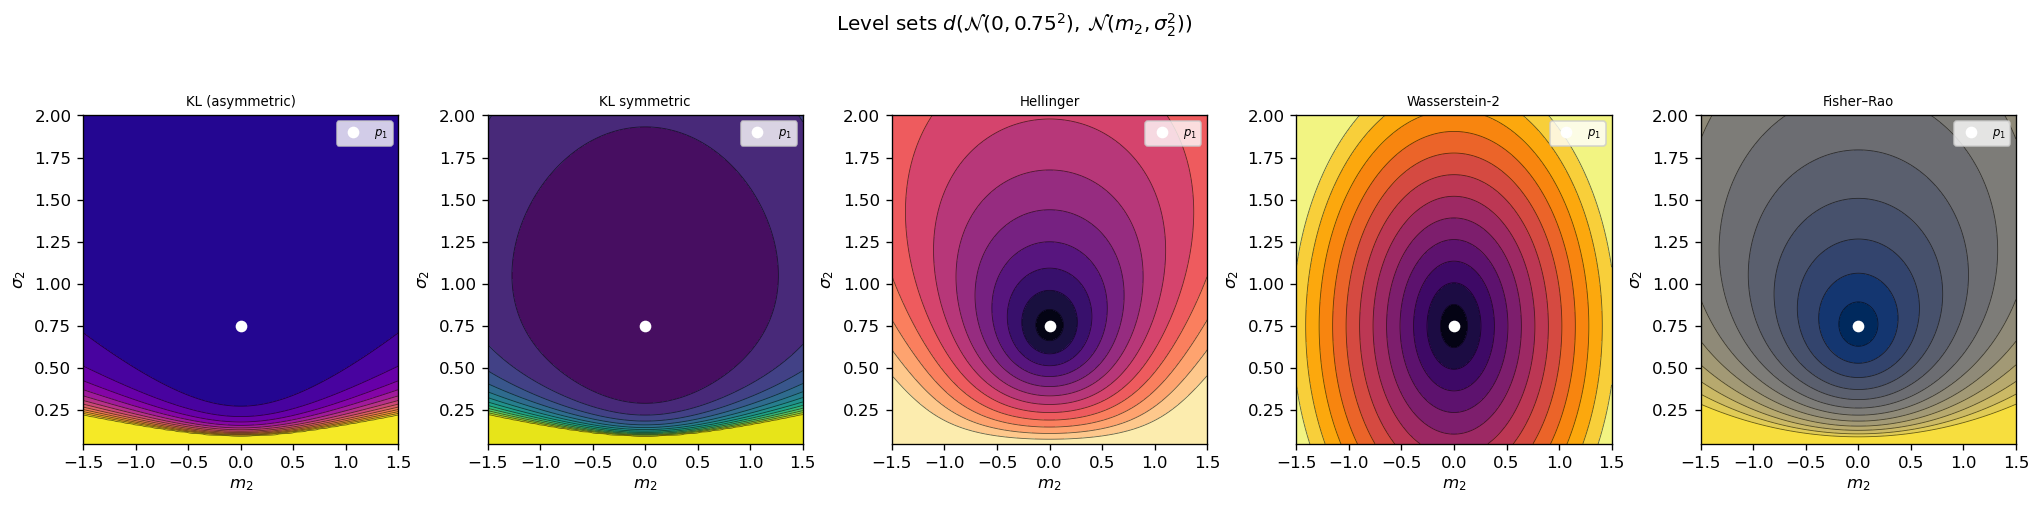

In [3]:
mN, sN = 300, 200
m_range = np.linspace(-1.5, 1.5, mN)
s_range = np.linspace(0.05, 2.0, sN)
S_grid, M_grid = np.meshgrid(s_range, m_range)

m1_ref, s1_ref = 0.0, 0.75

fig, axes = plt.subplots(1, 5, figsize=(17, 4))
cmaps_d = ['plasma', 'viridis', 'magma', 'inferno', 'cividis']
r = 14

for ax, (name, f), cmap in zip(axes, divergences.items(), cmaps_d):
    U = f(m1_ref, s1_ref, M_grid, S_grid)
    U = np.clip(U, 0, np.percentile(U, 95))
    U = U / (U.max() + 1e-14)

    ax.contourf(m_range, s_range, U.T, levels=r-1, cmap=cmap)
    ax.contour(m_range, s_range, U.T, levels=r-1, colors='k',
               linewidths=0.5, alpha=0.6)
    ax.plot(m1_ref, s1_ref, 'w.', ms=12, label='$p_1$')
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('$m_2$'); ax.set_ylabel('$\\sigma_2$')
    ax.legend(fontsize=7)

fig.suptitle(r'Level sets $d(\mathcal{N}(0, 0.75^2),\, \mathcal{N}(m_2, \sigma_2^2))$', y=1.04)
plt.tight_layout()
plt.show()

## Divergence along a path in parameter space

We move $p_2$ along a circular arc in $(m, \sigma)$ space and track all five divergences. This reveals how asymmetric the KL divergence is vs the symmetric metrics.

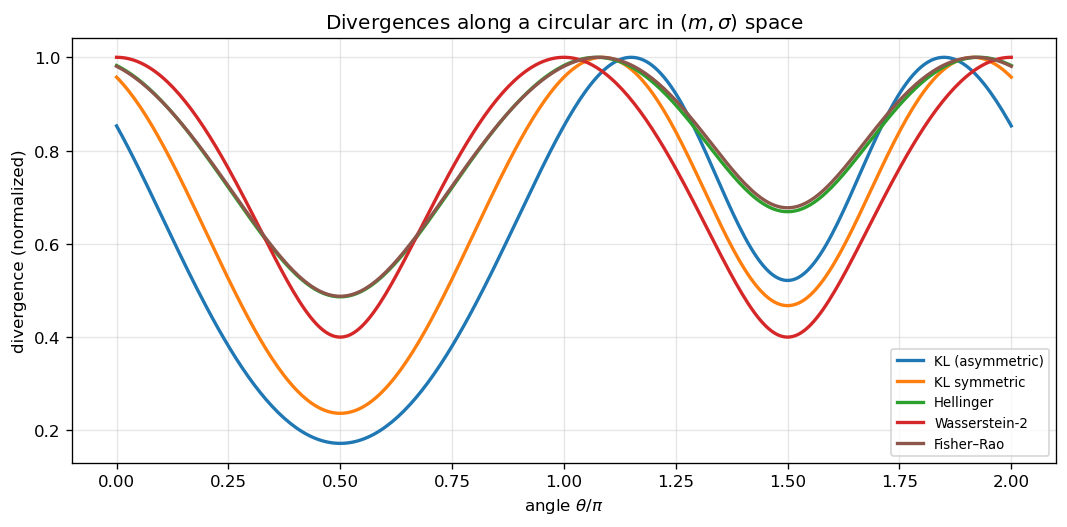

In [4]:
theta = np.linspace(0, 2*np.pi, 300)
r_path = 0.6
m2_path = m1_ref + r_path * np.cos(theta)
s2_path = s1_ref + r_path * 0.4 * np.sin(theta)
s2_path = np.maximum(s2_path, 0.05)

fig, ax = plt.subplots(figsize=(9, 4.5))
cols_d = plt.cm.tab10(np.linspace(0, 0.5, len(divergences)))

for (name, f), col in zip(divergences.items(), cols_d):
    d_vals = f(m1_ref, s1_ref, m2_path, s2_path)
    ax.plot(theta / np.pi, d_vals / (d_vals.max() + 1e-14), lw=2, color=col, label=name)

ax.set_xlabel(r'angle $\theta / \pi$'); ax.set_ylabel('divergence (normalized)')
ax.set_title('Divergences along a circular arc in $(m,\\sigma)$ space')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interactive: moving reference Gaussian

Change the reference Gaussian $(m_1, \sigma_1)$ and observe how the level curves of each divergence rotate and reshape.

In [5]:
from ipywidgets import Dropdown

def show_divergence(divergence='Fisher–Rao', m1=0.0, s1=0.75):
    f = divergences[divergence]
    U = f(m1, s1, M_grid, S_grid)
    U = np.clip(U, 0, np.percentile(U[np.isfinite(U)], 96))
    U = U / (U.max() + 1e-14)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(m_range, s_range, U.T, levels=15, cmap='viridis')
    ax.contour(m_range, s_range, U.T, levels=15, colors='k',
               linewidths=0.5, alpha=0.5)
    ax.plot(m1, s1, 'w.', ms=14, label=fr'$p_1=(m={m1:.1f},\sigma={s1:.2f})$')
    ax.set_xlabel('$m_2$'); ax.set_ylabel('$\\sigma_2$')
    ax.set_title(f'{divergence}: level sets around $p_1$')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

interact(show_divergence,
         divergence=Dropdown(options=list(divergences.keys()), description='divergence'),
         m1=FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.1, description='$m_1$'),
         s1=FloatSlider(value=0.75, min=0.1, max=1.5, step=0.05, description='$\\sigma_1$'));

interactive(children=(Dropdown(description='divergence', options=('KL (asymmetric)', 'KL symmetric', 'Hellinge…

## Bibliographical resources

- Kullback, S. and Leibler, R. A. (1951). On information and sufficiency. *Annals of Mathematical Statistics*, 22(1), 79–86.
- Hellinger, E. (1909). Neue Begründung der Theorie quadratischer Formen von unendlichvielen Veränderlichen. *Journal für die reine und angewandte Mathematik*, 136, 210–271.
- Villani, C. (2009). *Optimal Transport: Old and New*. Springer.
- Atkinson, C. and Mitchell, A. F. S. (1981). Rao's distance measure. *Sankhyā: The Indian Journal of Statistics*, 43(3), 345–365.
- Amari, S. and Nagaoka, H. (2000). *Methods of Information Geometry*. American Mathematical Society.